In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler

# Task 1: Student Performance Data Cleaning

In [2]:
# Load Data
df = pd.read_csv("studentsLab8Q1.csv")

# 1. Detect missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# 2. Convert Marks to numeric (forces 'abc' to become NaN)
df['Marks'] = pd.to_numeric(df['Marks'], errors='coerce')

# 3. Handle invalid values (e.g., negative age)
# Convert negative ages to NaN so we can fill them properly
df.loc[df['Age'] < 0, 'Age'] = np.nan

# 4. Handle missing values using Mean/Median and Mode
# Median for Age, Mean for Marks, Mode for City
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Marks'].fillna(df['Marks'].mean(), inplace=True)
df['City'].fillna(df['City'].mode()[0], inplace=True)

# 5. Remove duplicate records
df.drop_duplicates(inplace=True)

# Display results
print("\nSummary of changes made:")
print("- Converted 'abc' to missing in Marks, then filled with mean.")
print("- Replaced negative ages with median age.")
print("- Filled missing City with mode.")
print("- Removed duplicate rows.")
print("\nCleaned Dataset:\n", df.head())

Missing values before cleaning:
 Name     0
Age      1
Marks    1
City     1
dtype: int64

Summary of changes made:
- Converted 'abc' to missing in Marks, then filled with mean.
- Replaced negative ages with median age.
- Filled missing City with mode.
- Removed duplicate rows.

Cleaned Dataset:
      Name   Age  Marks       City
0     Ali  20.0   85.0     Lahore
1    Sara  21.0   90.0    Karachi
2   Ahmed  22.0   83.6     Lahore
3  Ayesha  21.0   88.0     Lahore
5   Bilal  21.0   70.0  Islamabad


/tmp/ipykernel_42955/2032140708.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_42955/2032140708.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

# Task 2: Sales Data Type Conversion & Validation

In [3]:
# Load Data
df = pd.read_csv("salesLab8Q2.csv")

print("Data types before conversion:\n", df.dtypes)

# Convert types using coerce to force invalid data to NaN
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

# Identify rows with incorrect data (any row that became NaN)
invalid_rows = df[df.isnull().any(axis=1)]
print("\nRows with invalid values:\n", invalid_rows)

# Drop the invalid records so we can safely convert Quantity to integer
df.dropna(inplace=True)
df['Quantity'] = df['Quantity'].astype(int)

print("\nData types after conversion:\n", df.dtypes)

Data types before conversion:
 Product      object
Price        object
Quantity    float64
Date         object
dtype: object

Rows with invalid values:
     Product   Price  Quantity       Date
2    Tablet     NaN       1.0 2024-03-01
3    Laptop  1200.0       NaN        NaT
5  Keyboard    50.0       5.0        NaT

Data types after conversion:
 Product             object
Price              float64
Quantity             int64
Date        datetime64[ns]
dtype: object


# Task 3: Feature Scaling Analysis

Skewness: 1.058222319538683


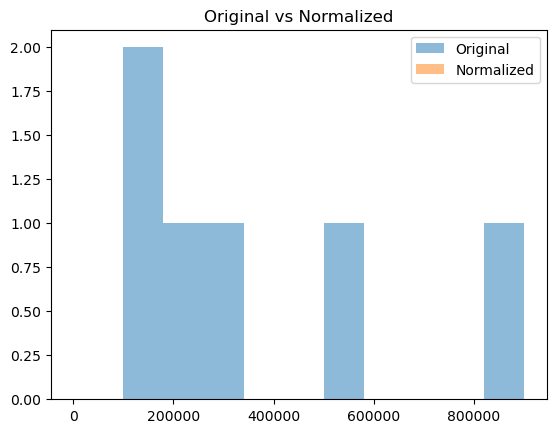

In [ ]:
# Load Data
df = pd.read_csv("housingLab8Q3.csv")

# Calculate skewness on the target column
skew_value = skew(df['Price'].dropna())
print("Skewness:", skew_value)

# Apply Min-Max Normalization
min_max = MinMaxScaler()
df['Price_Normalized'] = min_max.fit_transform(df[['Price']])

# Apply Standardization
std_scaler = StandardScaler()
df['Price_Standardized'] = std_scaler.fit_transform(df[['Price']])

# Plotting histograms
plt.hist(df['Price'], bins=10, alpha=0.5, label='Original')
plt.hist(df['Price_Normalized'], bins=10, alpha=0.5, label='Normalized')
plt.title("Original vs Normalized")
plt.legend()
plt.show()

# Task 4: Encoding Categorical Data

In [5]:
# Load Data
df = pd.read_csv("employeesLab8Q4.csv")

# Split dataset into train/test FIRST
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)

# Label Encoding -> Gender
le = LabelEncoder()
X_train['Gender'] = le.fit_transform(X_train['Gender'])
X_test['Gender'] = le.transform(X_test['Gender'])

# Ordinal Encoding -> Education (Bachelors < Masters < PhD)
oe = OrdinalEncoder(categories=[['Bachelors', 'Masters', 'PhD']])
X_train['Education'] = oe.fit_transform(X_train[['Education']])
X_test['Education'] = oe.transform(X_test[['Education']])

# One-Hot Encoding -> Department (Using pandas get_dummies)
X_train = pd.get_dummies(X_train, columns=['Department'])
X_test = pd.get_dummies(X_test, columns=['Department'])

print("Encoded Train Dataset:\n", X_train.head())

Encoded Train Dataset:
      Name  Education  Gender  Department_Finance  Department_HR  Department_IT
4   Bilal        1.0       1               False           True          False
2   Ahmed        2.0       1               False          False           True
0     Ali        0.0       1               False          False           True
3  Ayesha        0.0       0                True          False          False


# Task 5: Complete Preprocessing Pipeline

In [6]:
# Load Data
df = pd.read_csv("ecommerceLab8Q5.csv")

# 1. Fix invalid values & Convert data types
df['PurchaseAmount'] = pd.to_numeric(df['PurchaseAmount'], errors='coerce')

# 2. Handle missing values
df['PurchaseAmount'].fillna(df['PurchaseAmount'].mean(), inplace=True)
df['City'].fillna(df['City'].mode()[0], inplace=True)

# 3. Remove duplicates
df.drop_duplicates(inplace=True)

# 4. Apply feature scaling on PurchaseAmount
scaler = StandardScaler()
df['PurchaseAmount'] = scaler.fit_transform(df[['PurchaseAmount']])

# 5. Encode City (One-Hot Encoding)
df = pd.get_dummies(df, columns=['City'])

print("\nFinal Processed Dataset:\n", df.head())


Final Processed Dataset:
   CustomerID   Age  PurchaseAmount  ... City_Islamabad  City_Karachi  City_Lahore
0       C001  25.0       -0.610586  ...          False         False         True
1       C002   NaN        0.915879  ...          False          True        False
2       C003  30.0        0.000000  ...          False         False         True
3       C004  22.0       -0.992203  ...          False         False         True
4       C005  22.0       -0.992203  ...          False         False         True

[5 rows x 7 columns]


/tmp/ipykernel_42955/314207368.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PurchaseAmount'].fillna(df['PurchaseAmount'].mean(), inplace=True)
/tmp/ipykernel_42955/314207368.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

# Task 6: Train-Test Preprocessing Consistency

In [ ]:
# Load Data
df = pd.read_csv("studentsLab8Q1.csv")

# Clean the data first (handle the 'abc' in Marks and drop missing rows)
df['Marks'] = pd.to_numeric(df['Marks'], errors='coerce')
df.dropna(inplace=True) 

# Split data into train/test
X_train, X_test = train_test_split(df, test_size=0.3, random_state=42)

# 1. Apply Scaling to Marks
scaler = StandardScaler()
# Fit ONLY on training data, Transform BOTH
X_train['Marks_Scaled'] = scaler.fit_transform(X_train[['Marks']])
X_test['Marks_Scaled'] = scaler.transform(X_test[['Marks']])

# 2. Apply Encoding to City 
le = LabelEncoder()
# Fit ONLY on training data, Transform BOTH
X_train['City_Encoded'] = le.fit_transform(X_train['City'])
X_test['City_Encoded'] = le.transform(X_test['City'])

# Display the results
print("Train transformed values:\n", X_train[['Marks_Scaled', 'City_Encoded']].head())
print("\nTest transformed values:\n", X_test[['Marks_Scaled', 'City_Encoded']].head())

Train transformed values:
    Marks_Scaled  City_Encoded
4           1.0             1
5          -1.0             0

Test transformed values:
    Marks_Scaled  City_Encoded
0           1.0             1
